In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

from supabase import create_client, Client
from dotenv import load_dotenv
import os


c:\Users\Yusuf Rajabi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

TABLE_NAME = "tb_konsentrasi_gas"
COL_PM25 = "pm25_ugm3"
COL_TIMESTAMP = "created_at"

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

print("Supabase connected successfully.")


Supabase connected successfully.


In [3]:
import pandas as pd
from datetime import datetime, timedelta
from prophet import Prophet

# ===============================
# 1. Tentukan Rentang Waktu
# ===============================
seven_days_ago = datetime.now() - timedelta(days=14)
print(f"Mengambil data sejak {seven_days_ago.strftime('%Y-%m-%d %H:%M')}")

# ===============================
# 2. Pagination Supabase
# ===============================
all_data = []
page_size = 1000
offset = 0

COL_PM25 = "pm25_ugm3"
COL_NO= "no2_ugm3"
COL_PM10 = "pm10_ugm3"
COL_CO = "co_ugm3"
COL_SUHU = "temperature"
COL_KELEMBAPAN = "humidity"
COL_TIMESTAMP = "created_at"

while True:
    print(f"Mengambil data mulai offset {offset}...")

    response = supabase.table(TABLE_NAME) \
        .select(f"{COL_PM25},{COL_PM10}, {COL_NO}, {COL_CO}, {COL_SUHU}, {COL_KELEMBAPAN}, {COL_TIMESTAMP}") \
        .gte(COL_TIMESTAMP, seven_days_ago.isoformat()) \
        .order(COL_TIMESTAMP, desc=False) \
        .range(offset, offset + page_size - 1) \
        .execute()

    batch = response.data
    if not batch:
        break

    all_data.extend(batch)
    offset += len(batch)

print(f"Total data mentah: {len(all_data)} baris")

# ===============================
# 3. Data Cleaning
# ===============================
df_raw = pd.DataFrame(all_data)

if df_raw.empty:
    raise ValueError("Data kosong, tidak bisa melanjutkan")

# Konversi numerik
for col in [COL_PM25,COL_PM10,COL_NO, COL_CO, COL_SUHU, COL_KELEMBAPAN]:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

# Konversi timestamp + HILANGKAN TIMEZONE
df_raw[COL_TIMESTAMP] = (
    pd.to_datetime(df_raw[COL_TIMESTAMP], utc=True)
      .dt.tz_localize(None)
)

# Drop missing
df_raw.dropna(
    subset=[COL_PM25,COL_PM10,COL_NO, COL_CO, COL_SUHU, COL_KELEMBAPAN],
    inplace=True
)

# ===============================
# 4. Format KHUSUS Prophet
# ===============================
df = df_raw.rename(columns={
    COL_TIMESTAMP: "ds",
    COL_PM25: "y",
    COL_PM10: "pm10_ugm3",
    COL_NO: "no2_ugm3",
    COL_CO: "co_ugm3",
    COL_SUHU: "temperature",
    COL_KELEMBAPAN: "humidity"
})

df.sort_values("ds", inplace=True)

print("Data siap untuk Prophet")
print(df.head())


Mengambil data sejak 2026-03-26 19:14
Mengambil data mulai offset 0...
Mengambil data mulai offset 1000...
Mengambil data mulai offset 2000...
Mengambil data mulai offset 3000...
Mengambil data mulai offset 4000...
Mengambil data mulai offset 5000...
Mengambil data mulai offset 6000...
Mengambil data mulai offset 7000...
Mengambil data mulai offset 8000...
Mengambil data mulai offset 9000...
Mengambil data mulai offset 10000...
Mengambil data mulai offset 11000...
Mengambil data mulai offset 11652...
Total data mentah: 11652 baris
Data siap untuk Prophet
       y  pm10_ugm3  no2_ugm3   co_ugm3  temperature  humidity  \
0  62.83      80.19       0.0  50685.73         30.4      92.1   
1  60.54      76.70       0.0  55446.97         30.5      91.9   
2  56.66      70.66       0.0  55446.97         30.6      91.5   
3  72.70      52.54       0.0  57056.88         30.7      90.5   
4  69.88      90.41       0.0  57981.73         30.7      90.1   

                          ds  
0 2026-03-3

In [4]:
prophet_df = df.rename(columns={
    "created_at": "ds",
    "pm25_ugm3": "y"
})

prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)


In [5]:
TEST_RATIO = 0.2
split_idx = int(len(prophet_df) * (1 - TEST_RATIO))

train_df = prophet_df.iloc[:split_idx]
test_df  = prophet_df.iloc[split_idx:]

print(len(train_df), len(test_df))


9321 2331


In [6]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05
)

regressors = [
    "pm10_ugm3",
    "co_ugm3",
    "no2_ugm3",
    "temperature",
    "humidity"
]

for reg in regressors:
    model.add_regressor(reg)


In [7]:
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.05
)

regressors = [
    "pm10_ugm3",
    "co_ugm3",
    "no2_ugm3",
    "temperature",
    "humidity"
]

for reg in regressors:
    model.add_regressor(reg)


In [8]:
model.fit(train_df)


19:14:55 - cmdstanpy - INFO - Chain [1] start processing
19:14:56 - cmdstanpy - INFO - Chain [1] done processing


In [9]:
future = test_df.drop(columns=["y"])
forecast = model.predict(future)


In [10]:
y_true = test_df["y"].values
y_pred = forecast["yhat"].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2   = r2_score(y_true, y_pred)

print("=== Evaluasi Prophet Multivariat ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")


=== Evaluasi Prophet Multivariat ===
MAE  : 1.6859
RMSE : 2.2667
MAPE : 9.48%
R²   : -0.1296


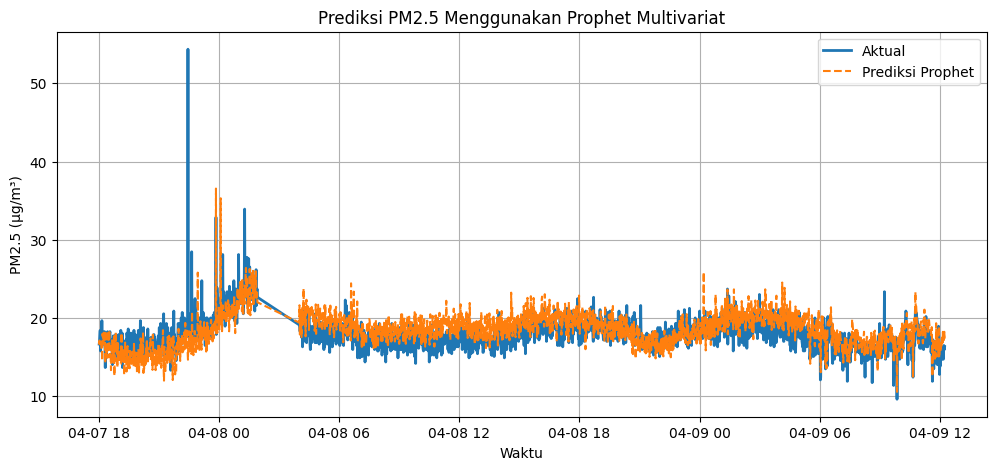

In [11]:
plt.figure(figsize=(12,5))
plt.plot(test_df["ds"], y_true, label="Aktual", linewidth=2)
plt.plot(test_df["ds"], y_pred, "--", label="Prediksi Prophet")
plt.xlabel("Waktu")
plt.ylabel("PM2.5 (µg/m³)")
plt.title("Prediksi PM2.5 Menggunakan Prophet Multivariat")
plt.legend()
plt.grid(True)
plt.show()


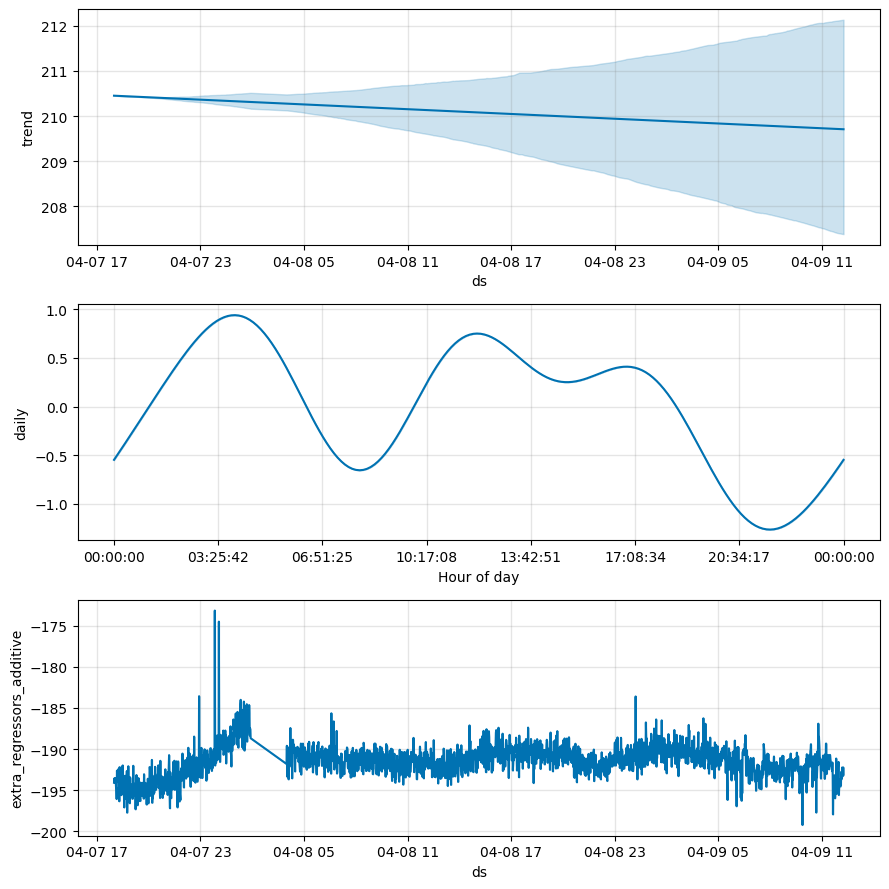

In [12]:
model.plot_components(forecast)
plt.show()
